In [1]:
import numpy as np
import glob, re, os

def find_folders(root):
    """Map N -> path of its NMentropy_swap.txt file, from subfolders named N<N>."""
    folders = {}
    for path in glob.glob(os.path.join(root, "N*")):
        if not os.path.isdir(path):
            continue
        m = re.fullmatch(r"N(\d+)", os.path.basename(path))
        if not m:
            continue
        N = int(m.group(1))
        fpath = os.path.join(path, "NMentropy_swap.txt")
        if os.path.isfile(fpath):
            folders[N] = fpath
    return dict(sorted(folders.items()))

def load_all(root):
    files = find_folders(root)
    if not files:
        raise FileNotFoundError(f"No N<N>/NMentropy_swap.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    error = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S, err = arr[:,0], arr[:,1], arr[:,2]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
            error   = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
        error[i, :]   = err
    
    return N_values, g_ref, entropy, error

N_values, g_values, entropy, error = load_all('results/28may2026/')

def f(N, g, tol=1e-6):
    """Return [entropy, error] for given N and g."""
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    return np.array([entropy[i, j], error[i, j]])

In [2]:
import numpy as np
from scipy.optimize import curve_fit


def linear_model(x, a, b):
    return a * x + b

def linear_fit_Svs_g(g_values, entropy, error):
    # popt contains optimal parameters [slope, intercept]
    # pcov is the 2x2 covariance matrix
    popt, pcov = curve_fit(linear_model, g_values, entropy, sigma=error, absolute_sigma=True)

    a = popt[0]
    # The [0, 0] element corresponds to the variance of the first parameter (slope)
    da = np.sqrt(pcov[0, 0])
    b = popt[1]
    return a,da,b

In [3]:
gmin = 1
gmin_index = int(np.where(g_values==gmin)[0][0])
glist = g_values[gmin_index:]

Nmin = 4
Nmin_index = int(np.where(N_values==Nmin)[0][0])
Nlist = N_values[Nmin_index:]

data = entropy[Nmin_index:,gmin_index:]
data_err = error[Nmin_index:,gmin_index:]
# err_safe = np.where(data_err > 0, data_err, np.nanmedian(data_err[data_err > 0]))

sizeN = len(Nlist)
coef = np.zeros((sizeN,3))

for i in range(sizeN):
    coef[i,:] = linear_fit_Svs_g(glist, data[i,:], data_err[i,:])

import matplotlib.pyplot as plt

# plt.plot(Nlist,slopes[:,0])
# plt.show()

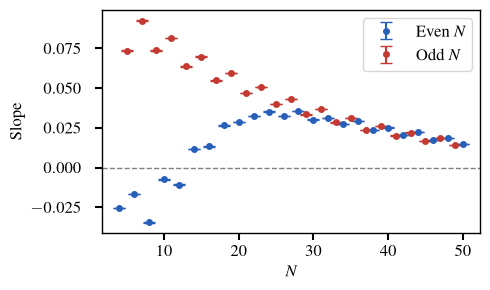

In [4]:
blue = (40/255, 95/255, 185/255)
red = (195/255, 58/255, 50/255)
# orange = (236/255, 133/255, 54/255)
# green = (85/255, 157/255, 155/255)
# blue = (0/255, 114/255, 178/255)
# red = (213/255, 94/255, 0/255)
green = (0/255, 158/255, 115/255)
orange = (230/255, 159/255, 0/255)
purple = (52/255, 21/255, 57/255)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'''
    \usepackage{nicefrac}
    \usepackage{siunitx}
    \usepackage{physics} 
    \usepackage[mathcal]{eucal}
    \DeclareFontFamily{OT1}{mathc}{}
    \DeclareFontShape{OT1}{mathc}{m}{it}{<-> mathc10}{}
    \DeclareMathAlphabet{\mathcal}{OT1}{mathc}{m}{it}
    '''
)
plt.rc('font', family='serif',serif='Times')
FontSize=12
tickpad=10
cmap = plt.colormaps['tab10']
fig, ax = plt.subplots(figsize=(5, 3))
ax.axhline(0, lw=1, ls='--', color='grey')
ax.errorbar(Nlist[0::2] ,coef[:,0][0::2], yerr=coef[:,1][0::2], fmt='o', ms=4, color=blue, label=r"Even $N$",capsize=4)
ax.errorbar(Nlist[1::2] ,coef[:,0][1::2], yerr=coef[:,1][1::2], fmt='o', ms=4, color=red, label=r"Odd $N$",capsize=4)
ax.set_xlabel(r"$N$", fontsize=FontSize)
ax.set_ylabel(r"Slope", fontsize=FontSize)
# ax.set_title("S vs g for fixed N")
ax.legend(fontsize=FontSize)
ax.grid(alpha=0.3)
ax.xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax.yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)

plt.setp(ax.spines.values(), linewidth=1)
plt.grid(False)
plt.tight_layout()

plt.savefig("slopes_vs_N.png",format = 'png', dpi=600)
plt.show()
plt.close()

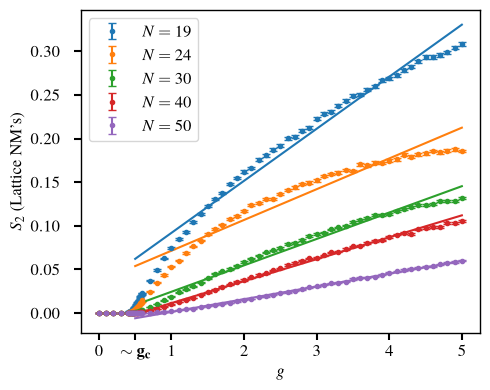

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
# Nlist = [10,13,16,19,22]
Nlist = [19,24,30,40,50]
# Nlist = [i for i in range(4,51) if i%2==0][::4]

x = np.linspace(0.5,5,200)
cmap = plt.colormaps['tab10']
k=0

for n in Nlist:
    i = int(np.where(N_values==n)[0][0])
    ax.errorbar(g_values , entropy[i,:], yerr=error[i,:], fmt='o', ms=3, label=rf"$N={n}$",capsize=3, color=cmap(k))

    ###### linear fit plot
    a,da,b = coef[i,:]
    ax.plot(x,linear_model(x,a,b), color=cmap(k))
    ######
    k+=1

# ax.set_xlim(xmin=-0.1,xmax=4.1)
ax.set_xlabel(r"$g$", fontsize=FontSize)
ax.set_ylabel(r"$S_2$ (Lattice NM's)", fontsize=FontSize)
ax.legend(fontsize=FontSize)
ax.grid(alpha=0.3)
ax.xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax.yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)
ax.set_xticks([0, 0.5, 1, 2,3,4,5])
ax.set_xticklabels([0, r'$\mathbf{\sim g_c}$', 1, 2,3,4,5])
plt.setp(ax.spines.values(), linewidth=1)
plt.grid(False)
plt.tight_layout()

plt.savefig("S2(latt_NM)_vs_g.png",format = 'png', dpi=600)
plt.show()